In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import torch
from torch.utils.data import DataLoader

import hydra
from omegaconf import DictConfig, OmegaConf

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors as mcolors

import what_where as ww
import what_where.constants as constants

import seaborn as sns
import tqdm 


In [27]:
results_dir = ww.utils.ROOT_DIR / "results" / ww.constants.RESULTS_DIR
figures_dir = results_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

In [28]:
cfg = ww.utils.load_config("config_gratings")
ww.utils.pretty_print_cfg(cfg)

seed: 42
checkpoint_elements: []
experiment_name: journal_v8
dataset:
  dataset_type: gratings
  name: gratings
  large_img_size: 64
  radius: 5
  cycles: 3
  center_left:
  - 25
  - 16
  center_right:
  - 25
  - 48
  center_random_shift: 0
  retinal_noise: 0.1
  max_contrast: 0.5
  'n': 10000
model:
  cnn:
    conv_channels:
    - 64
    - 128
    - 256
    pre_training:
      train_weights: false
      load_weights: true
      checkpoint_dir: pretrained_cnn/journal_v1
  rnn:
    hidden_size: 256
    n_layers: 3
    init_mlp_hidden_size: 64
  activity_noise: 0.1
  normalization_sigma: 1.0
  n_passes: 4
  gain:
    what:
      active: true
      type: learned
      operation: multiply
      min: 0.0
      max: 2.0
      sensitivity: 0.1
      mlp_hidden: 256
    where:
      active: true
      operation: multiply
      size: 16
      min: 0.0
      max: 2.0
      sensitivity: 0.1
      mlp_hidden: 256
    when:
      active: false
  name: what_where_gain
train:
  batch_size: 128
  shuf

In [29]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# loading the latest checkpoint
checkpoint_path = ww.utils.get_checkpoint_path(cfg)
print("checkpoint file: ", checkpoint_path)
# checkpoint_path = get_best_checkpoint_from_cfg(cfg)
if checkpoint_path is None:
    raise ValueError("No checkpoint found for config")
checkpoint = torch.load(checkpoint_path, weights_only=False)

# loading the config from the checkpoint
checkpoint_cfg = OmegaConf.create(checkpoint["config"])
# checkpoint_cfg.train.energy.st_sample_ratio = 1.0

readout = ww.model.GratingsReadout(checkpoint_cfg)
model = ww.model.Model(checkpoint_cfg, readout=readout)

dataset = ww.utils.get_dataset(cfg, transform=ww.utils.get_transform(cfg))
dataloader = DataLoader(dataset, batch_size=cfg.train.batch_size, shuffle=True)

# loading model weights
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

/home/eivinas/dev/what-where/checkpoints/gratings/journal_v8/what_where_gain/instance0
checkpoint:  /home/eivinas/dev/what-where/checkpoints/gratings/journal_v8/what_where_gain/instance0/checkpoint_027.pth 

checkpoint file:  /home/eivinas/dev/what-where/checkpoints/gratings/journal_v8/what_where_gain/instance0/checkpoint_027.pth


Model(
  (cnn): CNN(
    (conv_layers): ModuleList(
      (0): CNNLayer(
        (conv_layer): Conv2d(1, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
      )
      (1): CNNLayer(
        (conv_layer): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      )
      (2): CNNLayer(
        (conv_layer): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      )
    )
  )
  (rnn): RNN(
    (rnn_layers): ModuleList(
      (0): RNNLayer(
        (input_to_hidden): Linear(in_features=16384, out_features=256, bias=True)
        (hidden_to_hidden): Linear(in_features=256, out_features=256, bias=True)
      )
      (1-2): 2 x RNNLayer(
        (input_to_hidden): Linear(in_features=256, out_features=256, bias=True)
        (hidden_to_hidden): Linear(in_features=256, out_features=256, bias=True)
      )
    )
    (h0): MLP(
      (fc1): Linear(in_features=1, out_features=64, bias=True)
      (fc2): Linear(in_features=64, out_features=768, bias=True)
    

In [30]:
n_locations = 32
log_energy_cost = torch.tensor([-7.0]).to(device).unsqueeze(0)
conv_channels = cfg.model.cnn.conv_channels


n_iterations = 3  # number of iterations to average over to account for noise in the model
conv1_receptive_fields_full = np.zeros((n_iterations, conv_channels[0], 32, 32, n_locations, n_locations))
conv3_receptive_fields_full = np.zeros((n_iterations, conv_channels[2], 8, 8, n_locations, n_locations))


# basically zero gain to determine the receptive fields (suppresses towards neutral gain)
gain_suppression = {}
gain_suppression["conv1"] = torch.ones(1, 1, device=device) * 10.0
gain_suppression["conv2"] = torch.ones(1, 1, device=device) * 10.0
gain_suppression["conv3"] = torch.ones(1, 1, device=device) * 10.0


for i in range(n_iterations):
    print(f"Processing iteration {i+1}/{n_iterations}...")
    for x in range(n_locations):
        for y in range(n_locations):
            image = torch.zeros((1, 1, 64, 64), device=device)
            image[0, 0, x*2:(x+1)*2, y*2:(y+1)*2] = 10.0  # set a 2x2 patch to 1.0

            with torch.no_grad():
                out = model(image, log_energy_cost=log_energy_cost, n_passes=1, gain_suppression=gain_suppression)

            # conv1 receptive field
            conv1_activations = out[0]["activations"]["conv1"][0]
            conv1_receptive_fields_full[i, :, :, :, x, y] = conv1_activations.cpu().numpy()

            conv3_activations = out[0]["activations"]["conv3"][0]
            conv3_receptive_fields_full[i, :, :, :, x, y] = conv3_activations.cpu().numpy()

conv1_receptive_fields = conv1_receptive_fields_full.mean(axis=(0,1))
conv3_receptive_fields = conv3_receptive_fields_full.mean(axis=(0,1))



Processing iteration 1/3...
Processing iteration 2/3...
Processing iteration 3/3...


In [31]:
print("conv1 receptive fields shape: ", conv1_receptive_fields.shape)
print("conv3 receptive fields shape: ", conv3_receptive_fields.shape)

conv1 receptive fields shape:  (32, 32, 32, 32)
conv3 receptive fields shape:  (8, 8, 32, 32)


Text(0.5, 0.98, 'Receptive Fields at Stimulus Centers')

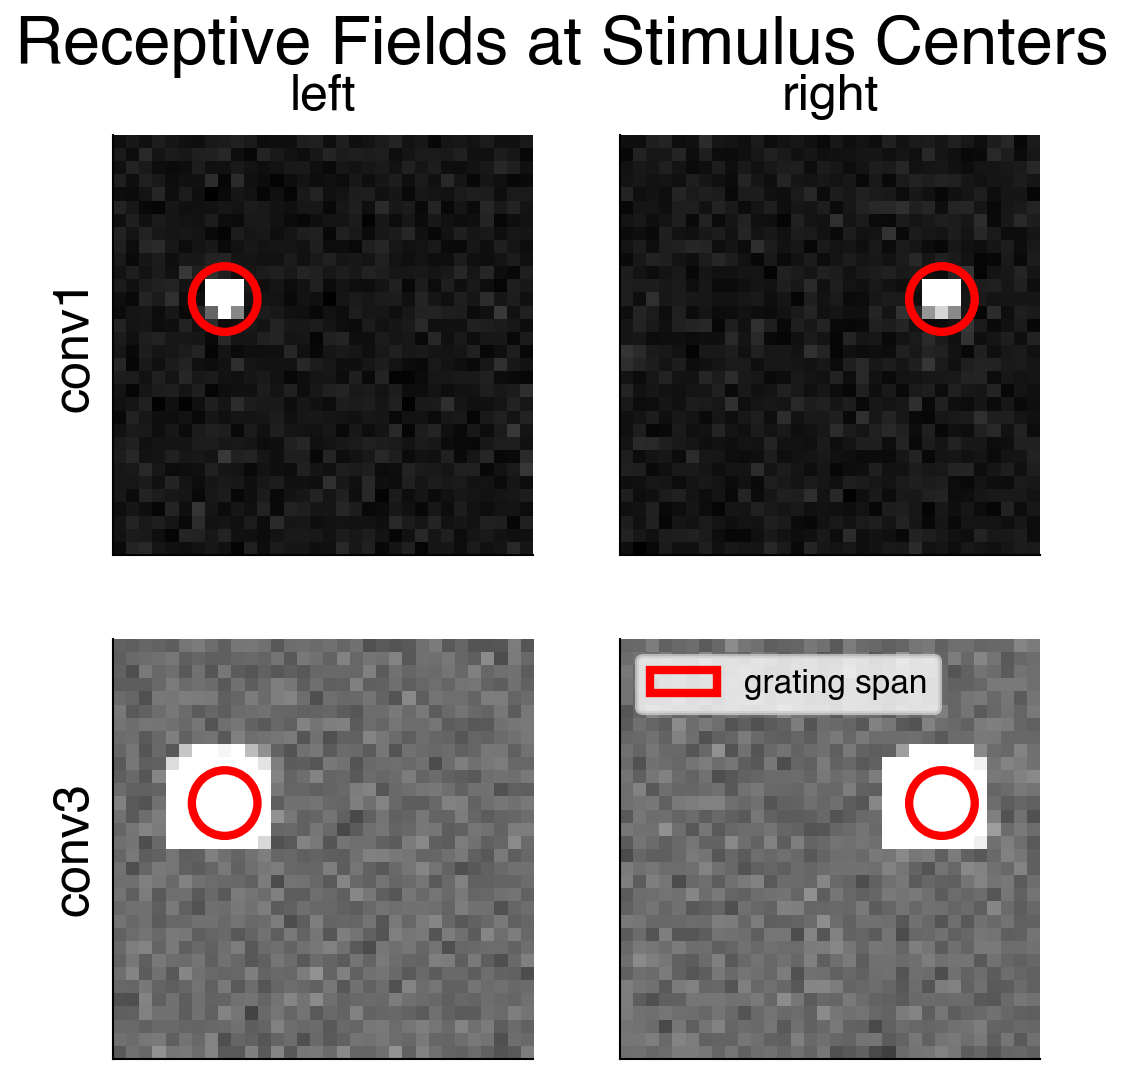

In [32]:
fig, axs = plt.subplots(2, 2, figsize=(4, 4))



for (i, conv_layer) in enumerate(["conv1", "conv3"]):
    for (j, location) in enumerate(["left", "right"]):
        pos = list(cfg.dataset.center_left) if location == "left" else list(cfg.dataset.center_right)


        if conv_layer == "conv1":
            ratio = 64 / 32
        else:
            ratio = 64 / 8

        unit_index = [int(pos[0] / ratio), int(pos[1] / ratio)]  # convert to conv1 receptive field coordinates
        # unit_index[0] += -1
        # unit_index[1] += 0
        if conv_layer == "conv1":
            axs[i,j].imshow(conv1_receptive_fields[*unit_index], cmap="gray", vmin=0.0, vmax=0.03)
        else:
            axs[i,j].imshow(conv3_receptive_fields[*unit_index], cmap="gray", vmin=0.0, vmax=0.03)

        # show stimulus (depends on the receptive field mapping size)
        circle_ratio = 64 / n_locations
        circle_pos = [int(pos[1] / circle_ratio), int(pos[0] / circle_ratio)]

        circle = plt.Circle(circle_pos, radius=cfg.dataset.radius/circle_ratio, color='red', fill=False, linewidth=2, label="grating span")
        axs[i,j].add_artist(circle)

        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])

        if i == 0:
            axs[i,j].set_title(f"{location}", fontsize=12)
        if j == 0:
            axs[i,j].set_ylabel(f"{conv_layer}", fontsize=12)

axs[1,1].legend(loc="upper left", fontsize=8)

fig.suptitle("Receptive Fields at Stimulus Centers", fontsize=16)